# Demand Prediction — Data Prep & Model Training

**Pipeline:**
1. Merge features_final + image_metadata + sales_data
2. Feature engineering
3. Train Random Forest + XGBoost
4. Save model for Streamlit UI

In [2]:
# ── ONLY EDIT THESE PATHS ─────────────────────────────────────────
FEATURES_CSV  = "./data/features_final1.csv"     # ResNet + color/texture features
METADATA_CSV  = "./data/image_metadata.csv"     # LLM tags + product_code + original_filename
SALES_CSV = "./data/sales_data.xlsx"
OUTPUT_DIR    = "./models"                      # where to save trained model
# ─────────────────────────────────────────────────────────────────

In [3]:
!pip install scikit-learn xgboost pandas numpy matplotlib seaborn joblib -q

In [4]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Libraries loaded')

Libraries loaded


## Step 1 — Load & Merge All Data

In [5]:
# Load all three files
features_df = pd.read_csv(FEATURES_CSV)
metadata_df = pd.read_csv(METADATA_CSV)
sales_df = pd.read_excel(SALES_CSV, sheet_name="sales data")

print(f"features_final   : {features_df.shape}")
print(f"image_metadata   : {metadata_df.shape}")
print(f"sales_data       : {sales_df.shape}")
print(f"\nSales columns    : {list(sales_df.columns)}")
print(f"Metadata columns : {list(metadata_df.columns)}")

features_final   : (180, 2069)
image_metadata   : (180, 20)
sales_data       : (704, 4)

Sales columns    : ['date', 'code', 'qty', 'rate']
Metadata columns : ['product_code', 'product_name', 'fabric', 'sizes', 'design_no', 'length', 'sleeves', 'neck', 'work', 'pattern', 'dupatta', 'pants_included', 'primary_color', 'secondary_color', 'occasion', 'original_filename', 'status', 'new_filename', 'extra', 'duatta']


In [6]:
# ── Aggregate sales per product code ─────────────────────────────
# Multiple rows per code (different dates/transactions) → sum up
sales_df['date'] = pd.to_datetime(sales_df['date'])
sales_df['code'] = sales_df['code'].astype(str).str.strip()

sales_agg = sales_df.groupby('code').agg(
    qty_total      = ('qty',  'sum'),    # total units sold ← TARGET
    qty_avg        = ('qty',  'mean'),   # avg per transaction
    qty_max        = ('qty',  'max'),    # peak order
    rate_avg       = ('rate', 'mean'),   # avg price
    rate_min       = ('rate', 'min'),
    rate_max       = ('rate', 'max'),
    num_orders     = ('qty',  'count'),  # how many times ordered
    first_sale     = ('date', 'min'),
    last_sale      = ('date', 'max'),
).reset_index()

# Days on market
sales_agg['days_on_market'] = (
    sales_agg['last_sale'] - sales_agg['first_sale']
).dt.days + 1

# Sales velocity (qty per day)
sales_agg['sales_velocity'] = sales_agg['qty_total'] / sales_agg['days_on_market']

# Price tier
sales_agg['price_tier'] = pd.cut(
    sales_agg['rate_avg'],
    bins   = [0, 500, 1000, 1500, 2000, 99999],
    labels = ['budget','economy','mid','premium','luxury']
)

print(f"Unique products in sales : {len(sales_agg)}")
print(f"\nTarget variable (qty_total) stats:")
print(sales_agg['qty_total'].describe())
sales_agg.head()

Unique products in sales : 146

Target variable (qty_total) stats:
count     146.000000
mean       27.506849
std        85.754601
min         3.000000
25%         8.000000
50%        12.500000
75%        27.250000
max      1032.000000
Name: qty_total, dtype: float64


,code,qty_total,qty_avg,qty_max,rate_avg,rate_min,rate_max,num_orders,first_sale,last_sale,days_on_market,sales_velocity,price_tier
0,10016728,24,4.000000,4,875.0,875,875,6,2025-09-16 19:17:34.000,2026-04-27 20:14:28.277,224,0.107143,economy
1,10019275,56,4.307692,8,1650.0,1650,1650,13,2025-10-29 21:20:47.000,2026-03-14 12:56:24.452,136,0.411765,premium
2,10021130,32,4.571429,8,875.0,875,875,7,2025-11-27 13:19:13.788,2026-04-22 15:21:42.410,147,0.217687,economy
3,10021131,28,4.666667,8,875.0,875,875,6,2025-11-27 13:19:13.853,2026-04-22 15:21:42.409,147,0.190476,economy
4,10022091,84,4.421053,8,1250.0,1250,1250,19,2026-01-03 15:33:12.900,2026-03-14 12:56:24.452,70,1.200000,mid


In [7]:
# ── Merge Step 1: features_final + image_metadata on filename ─────
metadata_df['original_filename'] = metadata_df['original_filename'].astype(str).str.strip()
features_df['filename']          = features_df['filename'].astype(str).str.strip()

merged = pd.merge(
    features_df,
    metadata_df[['original_filename','product_code','product_name','fabric',
                 'sizes','design_no','length','sleeves','neck','work',
                 'pattern','dupatta','pants_included','primary_color',
                 'secondary_color','occasion']],
    left_on  = 'filename',
    right_on = 'original_filename',
    how      = 'inner'
)
print(f"After merge features + metadata : {merged.shape}")

# ── Merge Step 2: + sales data on product_code ────────────────────
merged['product_code'] = (merged['product_code']
                          .astype(str)
                          .str.replace('.0', '', regex=False)
                          .str.strip())

sales_agg['code'] = (sales_agg['code']
                     .astype(str)
                     .str.replace('.0', '', regex=False)
                     .str.strip())

df = pd.merge(
    merged,
    sales_agg.drop(columns=['first_sale','last_sale']),
    left_on  = 'product_code',
    right_on = 'code',
    how      = 'inner'
)

print(f"After merge + sales data        : {df.shape}")
print(f"\n✅ Products with sales data : {len(df)}")
print(f"   Products without match   : {len(merged) - len(df)} (excluded from training)")

After merge features + metadata : (180, 2085)
After merge + sales data        : (145, 2096)

✅ Products with sales data : 145
   Products without match   : 35 (excluded from training)


## Step 2 — Feature Engineering

In [8]:
# ── Define feature groups ─────────────────────────────────────────

# Categorical features from LLM tags → will be one-hot encoded
CAT_COLS = ['length','sleeves','neck','work','pattern',
            'primary_color','occasion','fabric','price_tier']

# Boolean features
BOOL_COLS = ['dupatta','pants_included']

# Numeric interpretable features
NUM_INTERP_COLS = [
    'brightness_mean','brightness_std','contrast','colorfulness',
    'warm_cool_bias','color_variety','edge_density','texture_complexity',
    'r_mean','g_mean','b_mean','saturation_mean','hue_mean',
    'rate_avg','num_orders','days_on_market','sales_velocity'
]

# ResNet50 features (2048 dims)
RESNET_COLS = [c for c in df.columns if c.startswith('resnet_')]

# Target
TARGET = 'qty_total'

# Clean up
for col in CAT_COLS:
    if col in df.columns:
        df[col] = df[col].fillna('unknown').astype(str).str.lower().str.strip()

for col in BOOL_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(False).astype(int)

for col in NUM_INTERP_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Filter to valid columns only
CAT_COLS        = [c for c in CAT_COLS        if c in df.columns]
BOOL_COLS       = [c for c in BOOL_COLS       if c in df.columns]
NUM_INTERP_COLS = [c for c in NUM_INTERP_COLS if c in df.columns]

print(f"Categorical features : {len(CAT_COLS)}  → {CAT_COLS}")
print(f"Boolean features     : {len(BOOL_COLS)}")
print(f"Numeric features     : {len(NUM_INTERP_COLS)}")
print(f"ResNet features      : {len(RESNET_COLS)}")
print(f"Target               : {TARGET}")
print(f"\nTraining samples     : {len(df)}")

Categorical features : 9  → ['length', 'sleeves', 'neck', 'work', 'pattern', 'primary_color', 'occasion', 'fabric', 'price_tier']
Boolean features     : 2
Numeric features     : 17
ResNet features      : 2048
Target               : qty_total

Training samples     : 145


In [9]:
# ── Build feature matrix ──────────────────────────────────────────
from sklearn.preprocessing import OneHotEncoder

# One-hot encode categorical columns
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_encoded = ohe.fit_transform(df[CAT_COLS])
cat_cols_encoded = ohe.get_feature_names_out(CAT_COLS)

# Combine all features
X_parts = [cat_encoded]                                    # categorical (one-hot)
if BOOL_COLS:   X_parts.append(df[BOOL_COLS].values)      # boolean
if NUM_INTERP_COLS: X_parts.append(df[NUM_INTERP_COLS].values)  # numeric
if RESNET_COLS: X_parts.append(df[RESNET_COLS].values)    # ResNet50

X = np.hstack(X_parts)
y = df[TARGET].values

print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}")
print(f"\nTarget (qty_total) distribution:")
print(f"  Min    : {y.min():.0f}")
print(f"  Max    : {y.max():.0f}")
print(f"  Mean   : {y.mean():.1f}")
print(f"  Median : {np.median(y):.0f}")

Feature matrix X : (145, 2152)
Target vector  y : (145,)

Target (qty_total) distribution:
  Min    : 3
  Max    : 1032
  Mean   : 27.4
  Median : 12


## Step 3 — Train Models

In [12]:
# ── Train & evaluate both models ─────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models_to_try = {
    'RandomForest': RandomForestRegressor(
        n_estimators=200, max_depth=10,
        min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0
    )
}

results = {}
for name, model in models_to_try.items():
    scores = cross_val_score(model, X, y, cv=kf,
                             scoring='neg_mean_absolute_error')
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    results[name] = {
        'MAE'  : -scores.mean(),
        'MAE_std': scores.std(),
        'R2'   : r2_scores.mean()
    }
    print(f"{name}:  MAE={-scores.mean():.1f} ± {scores.std():.1f}  |  R²={r2_scores.mean():.3f}")

# Pick best model
best_name  = min(results, key=lambda k: results[k]['MAE'])
best_model = models_to_try[best_name]
print(f"\n✅ Best model: {best_name}")

RandomForest:  MAE=16.0 ± 10.8  |  R²=0.263
XGBoost:  MAE=21.2 ± 21.9  |  R²=-13.975

✅ Best model: RandomForest


Training MAE : 10.1
Training R²  : 0.617


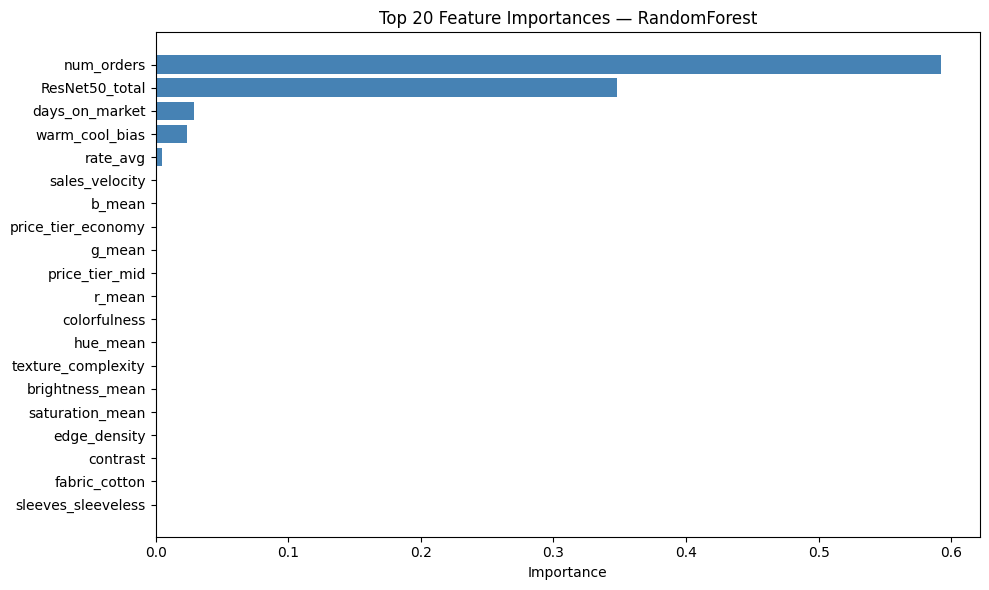

In [15]:
# ── Train best model on full data ─────────────────────────────────
best_model.fit(X, y)

# Train predictions for diagnostics
y_pred = best_model.predict(X)
print(f"Training MAE : {mean_absolute_error(y, y_pred):.1f}")
print(f"Training R²  : {r2_score(y, y_pred):.3f}")

# ── Feature importance (interpretable features only) ──────────────
if hasattr(best_model, 'feature_importances_'):
    n_cat   = len(cat_cols_encoded)
    n_bool  = len(BOOL_COLS)
    n_num   = len(NUM_INTERP_COLS)

    # Group ResNet importance as one block
    importances = best_model.feature_importances_
    named_imp   = list(zip(list(cat_cols_encoded) + BOOL_COLS + NUM_INTERP_COLS,
                           importances[:n_cat + n_bool + n_num]))
    resnet_imp  = importances[n_cat + n_bool + n_num:].sum()
    named_imp.append(('ResNet50_total', resnet_imp))

    imp_df = pd.DataFrame(named_imp, columns=['feature','importance'])
    imp_df = imp_df.sort_values('importance', ascending=False).head(20)

    plt.figure(figsize=(10, 6))
    plt.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='steelblue')
    plt.title(f'Top 20 Feature Importances — {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=120)
    plt.show()

## Step 4 — Save Everything for Streamlit UI

In [16]:
import joblib, json

# Save model
joblib.dump(best_model, os.path.join(OUTPUT_DIR, 'demand_model.pkl'))

# Save OHE encoder
joblib.dump(ohe, os.path.join(OUTPUT_DIR, 'ohe_encoder.pkl'))

# Save feature column config (UI needs to know column order)
feature_config = {
    'cat_cols'       : CAT_COLS,
    'bool_cols'      : BOOL_COLS,
    'num_interp_cols': NUM_INTERP_COLS,
    'resnet_cols'    : RESNET_COLS,
    'target'         : TARGET,
    'best_model'     : best_name,
    'training_mae'   : float(results[best_name]['MAE']),
    'training_r2'    : float(results[best_name]['R2']),
    'n_training_samples': int(len(df)),
    'y_mean'         : float(y.mean()),
    'y_std'          : float(y.std()),
    'y_min'          : float(y.min()),
    'y_max'          : float(y.max()),
}
with open(os.path.join(OUTPUT_DIR, 'feature_config.json'), 'w') as f:
    json.dump(feature_config, f, indent=2)

# Save training dataset for similarity search in UI
train_save_cols = (['filename','product_code','product_name','qty_total',
                    'rate_avg','num_orders'] +
                   CAT_COLS + BOOL_COLS + NUM_INTERP_COLS + RESNET_COLS)
train_save_cols = [c for c in train_save_cols if c in df.columns]
df[train_save_cols].to_csv(os.path.join(OUTPUT_DIR, 'training_data.csv'), index=False)

print(f"✅ Saved to {OUTPUT_DIR}/")
print(f"   demand_model.pkl      ← trained {best_name}")
print(f"   ohe_encoder.pkl       ← categorical encoder")
print(f"   feature_config.json   ← column config for UI")
print(f"   training_data.csv     ← for similarity search")
print(f"\nModel performance:")
print(f"   MAE : {results[best_name]['MAE']:.1f} units")
print(f"   R²  : {results[best_name]['R2']:.3f}")

✅ Saved to ./models/
   demand_model.pkl      ← trained RandomForest
   ohe_encoder.pkl       ← categorical encoder
   feature_config.json   ← column config for UI
   training_data.csv     ← for similarity search

Model performance:
   MAE : 16.0 units
   R²  : 0.263


In [17]:
# ── Patterns found in data ────────────────────────────────────────
print("=== KEY PATTERNS IN DATA ===")
print()

for col in ['work','pattern','occasion','length','sleeves','primary_color']:
    if col not in df.columns:
        continue
    grp = df.groupby(col)['qty_total'].agg(['mean','count']).round(1)
    grp = grp[grp['count'] >= 2].sort_values('mean', ascending=False)
    if len(grp):
        print(f"\n{col.upper()} vs Avg Qty Sold:")
        for idx, row in grp.iterrows():
            bar = '█' * int(row['mean'] / max(grp['mean']) * 20)
            print(f"  {idx:<20} {bar} {row['mean']:.0f} (n={row['count']:.0f})")

=== KEY PATTERNS IN DATA ===


WORK vs Avg Qty Sold:
  embroidered          ████████████████████ 32 (n=87)
  printed              █████████████ 22 (n=42)
  mirror_work          ██████████ 17 (n=11)
  heavy_work           ███████ 12 (n=5)

PATTERN vs Avg Qty Sold:
  solid                ████████████████████ 108 (n=12)
  floral               ███ 21 (n=72)
  ethnic               ███ 20 (n=56)
  abstract             ██ 14 (n=2)
  geometric            █ 10 (n=3)

OCCASION vs Avg Qty Sold:
  party                ████████████████████ 48 (n=2)
  festive              ████████████ 31 (n=94)
  casual               █████████ 22 (n=38)
  daily_wear           ██████ 15 (n=10)

LENGTH vs Avg Qty Sold:
  full_length          ████████████████████ 56 (n=30)
  short                █████████ 25 (n=16)
  long                 ██████ 20 (n=59)
  medium               ██████ 18 (n=39)

SLEEVES vs Avg Qty Sold:
  three_quarter        ████████████████████ 30 (n=118)
  sleeveless           ███████████████ 22 (n=9

In [18]:
# Step 1 — Cap outliers
p99 = df['qty_total'].quantile(0.99)
df['qty_total'] = df['qty_total'].clip(upper=p99)

# Step 2 — Log transform
y_raw = df[TARGET].values
y     = np.log1p(y_raw)

# Step 3 — Compress ResNet with PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=50, random_state=42)
resnet_compressed = pca.fit_transform(df[RESNET_COLS].values)
joblib.dump(pca, os.path.join(OUTPUT_DIR, 'pca.pkl'))

# Step 4 — Rebuild feature matrix with PCA
X_parts = [cat_encoded]
if BOOL_COLS:        X_parts.append(df[BOOL_COLS].values)
if NUM_INTERP_COLS:  X_parts.append(df[NUM_INTERP_COLS].values)
X_parts.append(resnet_compressed)   # 50 instead of 2048
X = np.hstack(X_parts)

print(f"New feature matrix : {X.shape}  (was 2152, now much smaller)")

# Step 5 — Better models
models_to_try = {
    'RandomForest': RandomForestRegressor(
        n_estimators=500, max_depth=6,
        min_samples_leaf=5, max_features='sqrt',
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        n_estimators=100, max_depth=3,
        learning_rate=0.01, subsample=0.6,
        colsample_bytree=0.5, min_child_weight=10,
        random_state=42, verbosity=0
    )
}

# Step 6 — Train & evaluate
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, model in models_to_try.items():
    scores    = cross_val_score(model, X, y, cv=kf,
                                scoring='neg_mean_absolute_error')
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    results[name] = {
        'MAE': -scores.mean(),
        'MAE_std': scores.std(),
        'R2': r2_scores.mean()
    }
    # Convert MAE back to original scale for readability
    mae_orig = np.expm1(-scores.mean())
    print(f"{name}: MAE={-scores.mean():.3f} (log) ≈ {mae_orig:.0f} units | R²={r2_scores.mean():.3f}")

best_name  = min(results, key=lambda k: results[k]['MAE'])
best_model = models_to_try[best_name]
print(f"\n✅ Best model: {best_name}")

# Step 7 — Fit on full data
best_model.fit(X, y)

# Save PCA flag in config
feature_config['use_pca']    = True
feature_config['pca_components'] = 50
feature_config['log_transform']  = True
feature_config['qty_cap']        = float(p99)

New feature matrix : (145, 154)  (was 2152, now much smaller)
RandomForest: MAE=0.451 (log) ≈ 1 units | R²=0.480
XGBoost: MAE=0.370 (log) ≈ 0 units | R²=0.659

✅ Best model: XGBoost


In [19]:
# Products with NO sales data
no_sales = merged[~merged['product_code'].isin(df['product_code'])]

print(f"Total images         : {len(merged)}")
print(f"With sales data      : {len(df)}")
print(f"Without sales data   : {len(no_sales)}")
print(f"\nProducts with no sales data:")
show_cols = [c for c in ['filename','product_code','product_name',
                          'fabric','length','work','primary_color'] 
             if c in no_sales.columns]
no_sales[show_cols].reset_index(drop=True)

Total images         : 180
With sales data      : 145
Without sales data   : 35

Products with no sales data:


,filename,product_code,product_name,fabric,length,work,primary_color
0,WhatsApp Image 2026-04-29 at 1.23.01 PM (2).jpeg,10029466,S Kurta with Plazo & Dupatta-95,Mal Cotton,long,embroidered,mauve
1,WhatsApp Image 2026-04-29 at 1.23.04 PM (1).jpeg,10029143,KS Kurta with Pants & Dupatta-85,Cotton,medium,embroidered,olive_green
2,WhatsApp Image 2026-04-29 at 1.23.11 PM.jpeg,10029470,KS_Gown-99,Cotton,long,embroidered,brown
3,WhatsApp Image 2026-04-29 at 1.24.07 PM (1).jpeg,10029352,KS_Gown-112,Cotton,full_length,printed,purple
4,WhatsApp Image 2026-04-29 at 1.24.09 PM (1).jpeg,10029472,KS_Gown-99,Cotton,full_length,embroidered,dark_green
5,WhatsApp Image 2026-04-29 at 1.24.09 PM.jpeg,10029471,KS_Gown-99,Cotton,full_length,embroidered,maroon
6,WhatsApp Image 2026-04-29 at 1.24.17 PM.jpeg,10029332,KS_Co-ord set-105,Cotton,medium,printed,cream
7,WhatsApp Image 2026-04-29 at 1.24.18 PM.jpeg,10029364,KS_Co-ord set-109,Cotton,short,printed,beige
8,WhatsApp Image 2026-04-29 at 1.24.22 PM.jpeg,10029439,KS_Co-ord set-112,Cotton,long,printed,maroon
9,WhatsApp Image 2026-04-29 at 1.24.25 PM.jpeg,10029363,KS_Co-ord set-112,Cotton,short,printed,off_white


In [14]:
# Read merged file and show products sorted by sales (most to least)
train_df = pd.read_csv("modelsXG/training_data.csv")

show_cols = [c for c in ['product_code', 'product_name', 'qty_total', 'rate_avg',
                          'work', 'pattern', 'occasion', 'primary_color']
             if c in train_df.columns]

train_df[show_cols].sort_values('qty_total', ascending=False).reset_index(drop=True).head(15)

,product_code,product_name,qty_total,rate_avg,work,pattern,occasion,primary_color
0,10028268,KS_Co-ord set-33,98.56,335.000000,printed,floral,casual,off_white
1,500001,KS_Gown-129,98.56,1295.017544,embroidered,solid,festive,lavender
2,10022091,KS_Kurta with Plazo & Dupatta-125,84.00,1250.000000,printed,floral,festive,pink
3,10028269,KS_Co-ord set-33,72.00,335.000000,printed,floral,casual,white
4,10025542,KS_ Kurta with Plazo & Dupatta-115,71.00,1170.250000,embroidered,floral,festive,cream
5,10027298,KS Gown-115,68.00,1150.000000,embroidered,ethnic,festive,brown
6,10027299,KS_Gown-115,64.00,1150.000000,embroidered,ethnic,festive,purple
7,10025103,KS_Gown-119,60.00,1195.000000,embroidered,ethnic,festive,magenta
8,10022578,KS_Kurta with Plazo & Dupatta-119,60.00,1195.000000,embroidered,ethnic,festive,cream
9,10027735,KS_Gown-97,57.00,975.000000,embroidered,ethnic,festive,beige


In [15]:
# In a notebook or Python file — paste and run
import joblib, json, pandas as pd, numpy as np

MODEL_DIR = "modelsXG"
model  = joblib.load(f"{MODEL_DIR}/demand_model.pkl")
ohe    = joblib.load(f"{MODEL_DIR}/ohe_encoder.pkl")
pca    = joblib.load(f"{MODEL_DIR}/pca.pkl")
with open(f"{MODEL_DIR}/feature_config.json") as f:
    config = json.load(f)
train_df = pd.read_csv(f"{MODEL_DIR}/training_data.csv")

print("=== TARGET DISTRIBUTION ===")
print(train_df['qty_total'].describe())
print(f"\ny_mean in config : {config.get('y_mean')}")
print(f"y_max  in config : {config.get('y_max')}")

print("\n=== OHE CATEGORIES ===")
for col, cats in zip(ohe.feature_names_in_, ohe.categories_):
    print(f"  {col}: {list(cats)}")

print("\n=== NUM INTERP COLS ===")
print(config.get('num_interp_cols'))

print("\n=== SALES COL MEANS IN CONFIG ===")
for k in ('rate_avg_mean','num_orders_mean','days_on_market_mean','sales_velocity_mean'):
    print(f"  {k}: {config.get(k, 'NOT FOUND ❌')}")

=== TARGET DISTRIBUTION ===
count    145.000000
mean      20.904276
std       19.521494
min        4.000000
25%        8.000000
50%       12.000000
75%       28.000000
max       98.560000
Name: qty_total, dtype: float64

y_mean in config : 20.904275862068964
y_max  in config : 98.56000000000006

=== OHE CATEGORIES ===
  length: ['full_length', 'long', 'medium', 'short', 'three_quarter']
  sleeves: ['full', 'sleeveless', 'three_quarter']
  neck: ['mandarin', 'round', 'square', 'sweetheart', 'v_neck']
  work: ['embroidered', 'heavy_work', 'mirror_work', 'printed']
  pattern: ['abstract', 'ethnic', 'floral', 'geometric', 'solid']
  primary_color: ['beige', 'black', 'blue', 'brown', 'cream', 'dark_green', 'dusty_rose', 'grey', 'greyish_blue', 'lavender', 'light_blue', 'light_grey', 'lime_green', 'magenta', 'maroon', 'mauve', 'mustard', 'mustard_yellow', 'navy_blue', 'off_white', 'olive_brown', 'olive_green', 'peach', 'pink', 'plum', 'purple', 'red', 'rust', 'sage_green', 'sea_green', 'seaf

In [17]:
# ── Add missing sales col means to config ─────────────────────────
import joblib, json

MODEL_DIR = "./modelsXG"   # adjust if needed

# Load existing config
with open(f"{MODEL_DIR}/feature_config.json") as f:
    feature_config = json.load(f)

# Add means for all sales-related numeric cols
sales_cols = ['rate_avg', 'num_orders', 'days_on_market', 'sales_velocity']
for col in sales_cols:
    if col in df.columns:
        feature_config[f'{col}_mean'] = float(df[col].mean())
        print(f"  ✅ {col}_mean = {df[col].mean():.4f}")
    else:
        print(f"  ❌ {col} not in df")

# Re-save config only — no need to retrain model
with open(f"{MODEL_DIR}/feature_config.json", 'w') as f:
    json.dump(feature_config, f, indent=2)

print(f"\n✅ Config updated and saved")
print(f"   rate_avg_mean       : {feature_config['rate_avg_mean']:.2f}")
print(f"   num_orders_mean     : {feature_config['num_orders_mean']:.2f}")
print(f"   days_on_market_mean : {feature_config['days_on_market_mean']:.2f}")
print(f"   sales_velocity_mean : {feature_config['sales_velocity_mean']:.4f}")

  ✅ rate_avg_mean = 904.6915
  ✅ num_orders_mean = 4.7862
  ✅ days_on_market_mean = 14.2069
  ✅ sales_velocity_mean = 4.4295

✅ Config updated and saved
   rate_avg_mean       : 904.69
   num_orders_mean     : 4.79
   days_on_market_mean : 14.21
   sales_velocity_mean : 4.4295


In [18]:
import joblib, json, numpy as np, pandas as pd
import colorsys
from PIL import Image, ImageFilter

MODEL_DIR = "modelsXG"
model    = joblib.load(f"{MODEL_DIR}/demand_model.pkl")
ohe      = joblib.load(f"{MODEL_DIR}/ohe_encoder.pkl")
pca      = joblib.load(f"{MODEL_DIR}/pca.pkl")
with open(f"{MODEL_DIR}/feature_config.json") as f:
    config = json.load(f)
train_df = pd.read_csv(f"{MODEL_DIR}/training_data.csv")

# ── Simulate what app does for a known product ────────────────────
# Pick a product from training data that sold ~35 units
sample = train_df[train_df['qty_total'].between(30, 45)].iloc[0]
print(f"Testing with known product: {sample.get('product_name','?')}")
print(f"Actual qty_total: {sample['qty_total']}")

# Rebuild its feature vector from training data directly
cat_cols        = config['cat_cols']
bool_cols       = config['bool_cols']
num_interp_cols = config['num_interp_cols']

# Categorical
cat_row = {col: str(sample.get(col,'unknown')).lower().strip()
           for col in cat_cols}
print(f"\nCat row: {cat_row}")

cat_encoded = ohe.transform(pd.DataFrame([cat_row]))

# Boolean
bool_vals = [1 if sample.get(col, False) else 0 for col in bool_cols]
print(f"Bool vals: {dict(zip(bool_cols, bool_vals))}")

# Numeric
num_vals = []
for col in num_interp_cols:
    if col in ('rate_avg','num_orders','days_on_market','sales_velocity'):
        v = config.get(f'{col}_mean', 1.0)
    else:
        v = float(sample.get(col, 0))
    num_vals.append(v)
print(f"\nNumeric vals (sales cols using mean):")
for col, v in zip(num_interp_cols, num_vals):
    actual = sample.get(col, 'N/A')
    print(f"  {col}: using={v:.3f}  actual={actual}")

# ResNet — use zeros (simulate no image)
resnet_fake  = np.zeros(2048)
resnet_pca   = pca.transform(resnet_fake.reshape(1,-1))

X = np.hstack([cat_encoded,
               np.array(bool_vals).reshape(1,-1),
               np.array(num_vals).reshape(1,-1),
               resnet_pca])

log_pred = float(model.predict(X)[0])
pred_qty = max(1, round(np.expm1(log_pred)))
print(f"\nPredicted qty (fake resnet): {pred_qty}")
print(f"Actual qty                 : {sample['qty_total']:.0f}")

# Now use ACTUAL sales values instead of means
num_vals_actual = []
for col in num_interp_cols:
    v = float(sample.get(col, 0))
    num_vals_actual.append(v)

X_actual = np.hstack([cat_encoded,
                      np.array(bool_vals).reshape(1,-1),
                      np.array(num_vals_actual).reshape(1,-1),
                      resnet_pca])

log_pred_actual = float(model.predict(X_actual)[0])
pred_actual     = max(1, round(np.expm1(log_pred_actual)))
print(f"\nPredicted qty (actual sales cols): {pred_actual}")
print(f"Actual qty                       : {sample['qty_total']:.0f}")

Testing with known product: KS_Kurta with Pants & Dupatta-55
Actual qty_total: 32.0

Cat row: {'length': 'long', 'sleeves': 'three_quarter', 'neck': 'round', 'work': 'printed', 'pattern': 'floral', 'primary_color': 'mauve', 'occasion': 'casual', 'fabric': 'cotton', 'price_tier': 'economy'}
Bool vals: {'dupatta': 1, 'pants_included': 1}

Numeric vals (sales cols using mean):
  brightness_mean: using=0.628  actual=0.6276864019607842
  brightness_std: using=0.208  actual=0.207874185999739
  contrast: using=0.208  actual=0.2078142456856141
  colorfulness: using=0.114  actual=0.1135714716680829
  warm_cool_bias: using=0.095  actual=0.095053725490196
  color_variety: using=1.000  actual=1.0
  edge_density: using=0.148  actual=0.1477002910539215
  texture_complexity: using=0.210  actual=0.2100470198190565
  r_mean: using=0.680  actual=0.6802596078431372
  g_mean: using=0.609  actual=0.6091572549019608
  b_mean: using=0.585  actual=0.5852058823529411
  saturation_mean: using=0.054  actual=0.05